## 1. Importing Packages

In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
from itertools import combinations
from sklearn.model_selection import StratifiedGroupKFold

## 2. Data Loading 

In [264]:
df = pd.read_csv("./data/heart_disease_data.csv")

In [265]:
df.head()

,ID,Survive,Gender,Smoke,Diabetes,Age,Ejection Fraction,Sodium,Creatinine,Platelets,Creatine phosphokinase,Blood Pressure,Hemoglobin,Height,Weight,Favorite color
0,TIG1GE,0,Male,Yes,Normal,50,Low,141,0.7,266000.0,185,105,12.3,180,93,green
1,VXUCV9,1,Male,No,Normal,75,Low,134,2.5,224000.0,99,162,13.0,140,47,black
2,AFH4F1,1,Female,No,Pre-diabetes,80,Low,135,1.3,192000.0,776,179,12.4,150,61,white
3,ZK6PAC,0,Male,No,Normal,-60,Low,136,0.9,228000.0,2261,136,15.3,130,48,yellow
4,6CVBRT,0,Female,No,Normal,70,Low,141,0.9,358000.0,1202,171,13.3,177,64,blue


In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      15000 non-null  object 
 1   Survive                 15000 non-null  object 
 2   Gender                  15000 non-null  object 
 3   Smoke                   15000 non-null  object 
 4   Diabetes                15000 non-null  object 
 5   Age                     15000 non-null  int64  
 6   Ejection Fraction       15000 non-null  object 
 7   Sodium                  15000 non-null  int64  
 8   Creatinine              14501 non-null  float64
 9   Platelets               15000 non-null  float64
 10  Creatine phosphokinase  15000 non-null  int64  
 11  Blood Pressure          15000 non-null  int64  
 12  Hemoglobin              15000 non-null  float64
 13  Height                  15000 non-null  int64  
 14  Weight                  15000 non-null

In [267]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,15000.0,57.428467,23.411173,-95.0,50.0,60.0,70.0,95.0
Sodium,15000.0,136.604267,4.364890,113.0,134.0,137.0,140.0,148.0
Creatinine,14501.0,1.410195,1.044535,0.5,0.9,1.1,1.4,9.4
Platelets,15000.0,263096.016490,98056.330340,25100.0,211000.0,262000.0,304000.0,850000.0
Creatine phosphokinase,15000.0,580.151800,955.418765,23.0,115.0,250.0,582.0,7861.0
Blood Pressure,15000.0,103.676667,39.700138,40.0,70.0,100.0,137.0,179.0
Hemoglobin,15000.0,12.910667,2.500152,9.0,10.7,12.7,15.1,17.5
Height,15000.0,159.475200,17.344439,130.0,144.0,160.0,174.0,189.0
Weight,15000.0,69.340467,25.298287,19.0,50.0,66.0,87.0,141.0


The dataset represents the survival status of patients with coronary heart disease, where every row represents the data of a specific patient with heart disease. The most important column is `Survive`, which is the target variable to be predicted. The remaining columns indicate patient demographics (`Gender`, `Age`, `Height`, `Weight`), lifestyle habits and preexisting conditions (`Smoke`, `Diabetes`), personal preferences (`Favorite color`) and the rest are clinical measurements. 

## 3. Data Exploration

In [268]:
missing_values = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Proportion": df.isna().sum() * 100 / len(df)
}).sort_values("Missing Proportion", ascending= False)

missing_values

,Missing Count,Missing Proportion
Creatinine,499,3.326667
ID,0,0.000000
Survive,0,0.000000
Gender,0,0.000000
Smoke,0,0.000000
Diabetes,0,0.000000
Age,0,0.000000
Ejection Fraction,0,0.000000
Sodium,0,0.000000
Platelets,0,0.000000


The only missing values appears to be from the `Creatinine` column (499 entries), which accounts for 3.33% of the entire dataset. The measures needed to be taken will be addressed subsequently afterr performing thorough Univariate Analysis of the column.

In [269]:
df.duplicated().sum()

0

No duplicate values found in the dataset.

## 4. Univariate Analysis

### ID

In [270]:
df["ID"].nunique()

14042

In [271]:
df["ID"].duplicated().sum()

958

In [272]:
df[df["ID"].duplicated(keep=False)].sort_values(["ID", "Age"])

,ID,Survive,Gender,Smoke,Diabetes,Age,Ejection Fraction,Sodium,Creatinine,Platelets,Creatine phosphokinase,Blood Pressure,Hemoglobin,Height,Weight,Favorite color
11833,00G7VD,0,Female,No,Pre-diabetes,65,Low,136,1.00,257000.0,720,66,10.2,183,64,green
5817,00G7VD,1,Female,No,Pre-diabetes,82,Low,145,1.00,321000.0,855,152,9.3,154,88,white
4750,00IUNH,0,Male,No,Diabetes,45,Normal,136,1.00,377000.0,308,139,14.9,189,76,red
13763,00IUNH,0,Male,No,Pre-diabetes,50,Low,130,0.70,260000.0,121,109,10.2,172,67,red
7837,03HS9P,0,Female,No,Pre-diabetes,50,Low,136,0.70,232000.0,1051,50,10.1,169,44,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,ZXGNKE,1,Male,No,Normal,75,Low,134,1.83,225000.0,582,79,11.2,164,77,blue
5120,ZY89HT,1,Male,No,Normal,45,Low,145,1.00,385000.0,582,91,12.4,131,58,green
5647,ZY89HT,No,Male,Yes,Normal,70,Normal,145,1.10,176000.0,171,168,10.9,171,74,blue
1970,ZYRYZQ,0,Male,Yes,Normal,53,Normal,138,0.70,249000.0,1808,177,10.7,157,72,yellow


No exact duplicate rows were found in the dataset. However, 958 `ID` values appear more than once, indicating that some patients have multiple entries corresponding to different visits, as shown by differences in the `Age` column as well as differing clinical measurements.

This is consistent with heart disease patients requiring frequent checkups to monitor disease progression. Notably, the `Survive` column may not be constant within a given `ID`, indicating that the target reflects a per-visit outcome rather than a fixed patient -level trait. In this instance, retaining repeated entries from the same `ID` is valid as each row represents a distinct clinical snapshot relevant to predicting the target variable.

So as to prevent data leakage from a single patient appearing in both train and test sets, splits will be grouped by `ID` rather than performed on individual rows.

### Survive (Target Variable)

In [273]:
df["Survive"].value_counts()

Survive
0      9581
1      4552
No      604
Yes     263
Name: count, dtype: int64

In [274]:
df["Survive"] = df["Survive"].replace({"No": "0", "Yes": "1"}).astype(int)

In [275]:
df["Survive"].value_counts(normalize=True)

Survive
0    0.679
1    0.321
Name: proportion, dtype: float64

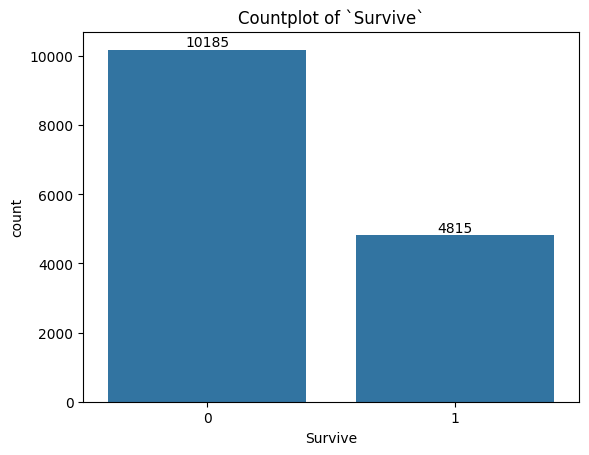

In [276]:
survive_plot = sns.countplot(data=df, x="Survive")
survive_plot.bar_label(survive_plot.containers[0])
plt.title("Countplot of `Survive`")
plt.show()

Initial exploration of the `Survive` column showed that there were binary values represented in strings ("0", "1") as well as Yes and No values. String methods were used to convert Yes and No values to "1" and "0" respectively to adhere to the binary nature of the column.

Further examination of the target variable showed mild class imbalance, with 67.9% of patients surviving (0) and 32.1% of patients not surviving (1). Stratified splitting will be considered during the data splitting process to ensure even distribution of data in both classes.

### Gender

In [277]:
df["Gender"].value_counts(normalize=True)

Gender
Male      0.650467
Female    0.349533
Name: proportion, dtype: float64

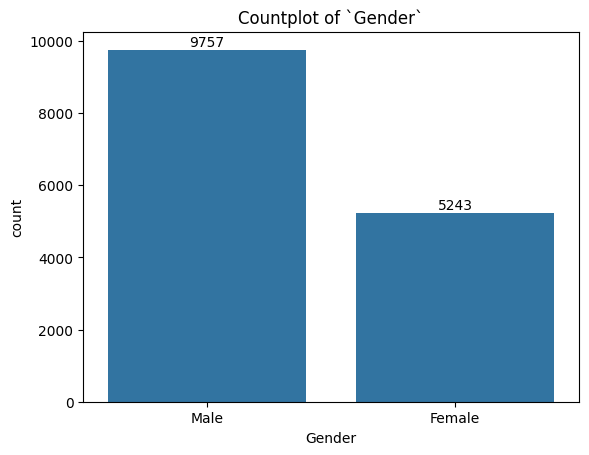

In [278]:
gender_plot = sns.countplot(data=df, x="Gender")
gender_plot.bar_label(gender_plot.containers[0])
plt.title("Countplot of `Gender`")
plt.show()

65.0% of heart disease patients are Male whereas the remaining 35.0% are Female. This is considered to be a mild imbalance but still fair distribution.

### Smoke

In [279]:
df["Smoke"].value_counts()

Smoke
No     9710
Yes    4707
NO      399
YES     184
Name: count, dtype: int64

In [280]:
df["Smoke"] = df["Smoke"].str.capitalize()

In [281]:
df["Smoke"].value_counts(normalize=True)

Smoke
No     0.673933
Yes    0.326067
Name: proportion, dtype: float64

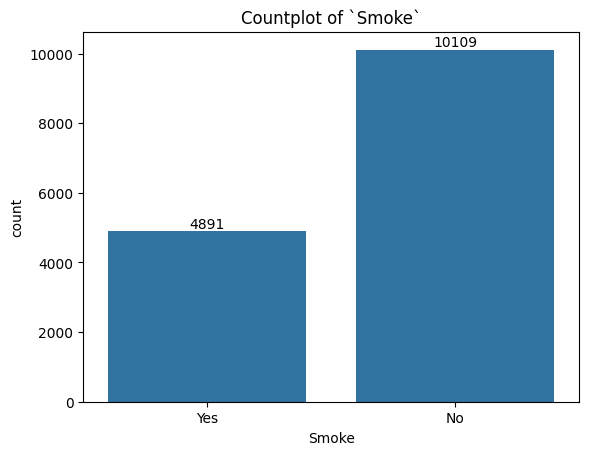

In [282]:
smoke_plot = sns.countplot(data=df, x="Smoke")
smoke_plot.bar_label(smoke_plot.containers[0])
plt.title("Countplot of `Smoke`")
plt.show()

The `Smoke` column shows Yes and No values with inconsistent capitalization, which were made consistent using string methods. The countplot then shows 32.6% of Smokers and 67.4% of Non-Smokers, which is a mild imbalance that does not require any measures to handle.

### Diabetes

In [283]:
df["Diabetes"].value_counts(normalize=True)

Diabetes
Normal          0.585933
Pre-diabetes    0.208267
Diabetes        0.205800
Name: proportion, dtype: float64

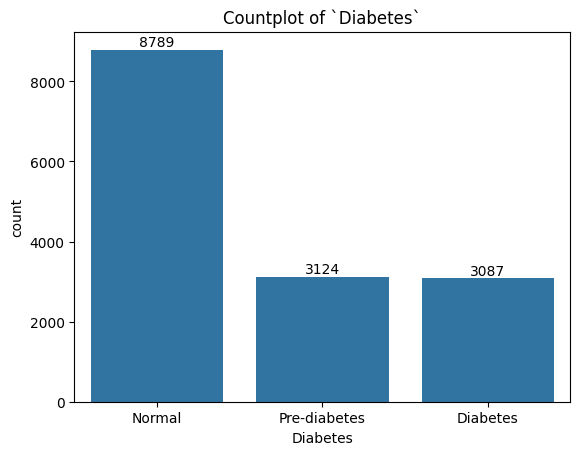

In [284]:
diabetes_plot = sns.countplot(data=df, x="Diabetes")
diabetes_plot.bar_label(diabetes_plot.containers[0])
plt.title("Countplot of `Diabetes`")
plt.show()

The countplot shows 58.6% of patients not having diabetes, with 20.8% being pre-diabetic and the remaining 20.6% being diabetic. This distribution of classes is relatively balanced. Given the progression of having no diabetes > pre-diabetic > diabetic, ordinal encoding will be considered for the `Diabetes` column.

### Age 

Text(0.5, 1.0, 'Histogram of `Age`')

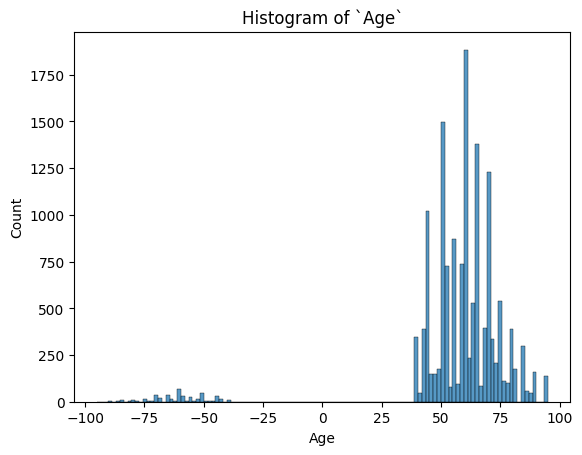

In [285]:
sns.histplot(data=df, x="Age")
plt.title("Histogram of `Age`")

In [286]:
len(df[df["Age"] < 0])

430

In [287]:
df[df["Age"] < 0]

,ID,Survive,Gender,Smoke,Diabetes,Age,Ejection Fraction,Sodium,Creatinine,Platelets,Creatine phosphokinase,Blood Pressure,Hemoglobin,Height,Weight,Favorite color
3,ZK6PAC,0,Male,No,Normal,-60,Low,136,0.90,228000.00,2261,136,15.3,130,48,yellow
14,NQRZFG,0,Male,No,Normal,-40,Low,137,0.90,255000.00,129,82,9.1,140,37,white
24,W5R4KE,1,Male,Yes,Normal,-85,Low,132,1.00,243000.00,5882,79,15.2,160,84,red
112,1EQGA7,1,Male,No,Normal,-45,Low,135,1.60,126000.00,582,130,12.7,177,69,black
119,DLJSRR,0,Female,No,Diabetes,-58,Normal,137,0.80,300000.00,200,53,9.1,155,71,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14937,GSLU48,1,Female,No,Normal,-86,Low,134,1.83,263358.03,582,58,12.8,137,57,yellow
14959,QOYS4C,0,Male,Yes,Normal,-50,Normal,140,NaN,147000.00,582,129,14.2,143,43,yellow
14961,VLUHXM,0,Female,No,Diabetes,-50,Low,134,1.00,279000.00,582,135,9.3,171,63,black
14987,C47221,0,Female,Yes,Normal,-70,Normal,140,0.80,317000.00,92,165,16.0,168,92,blue


In [288]:
df["Age"] = df["Age"].abs()

Text(0.5, 1.0, 'Histogram of `Age`')

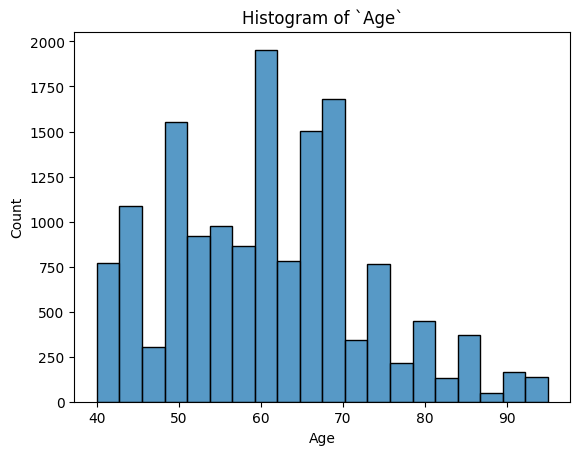

In [289]:
sns.histplot(data=df, x="Age", bins = 20)
plt.title("Histogram of `Age`")

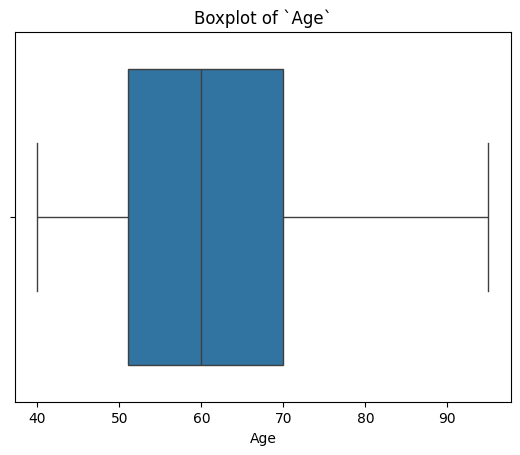

In [290]:
sns.boxplot(data=df, x="Age")
plt.title("Boxplot of `Age`")
plt.show()

In [291]:
df["Age"].skew()

0.4090195622047115

430 values in the `Age` column appeared to negative, which is likely due to a data entry error as their absolute values are still considered to be of use.

The boxplot and histogram shows that the median age of heart disease patients is 60. The boxplot justifies this by showing that the middle 50% of patients (25th to 75th percentile) are between the ages of 50 and 70. The right whisker appears to be substantially longer than the left whisker, which makes sense as the histogram shows a substantial number of records with patients above the age of 80 that has led to long right tail. This also justifies that the `Age` column is slightly right skewed as seen by the .skew() value of 0.41

The boxplot also shows no apparent outliers

### Ejection Fraction

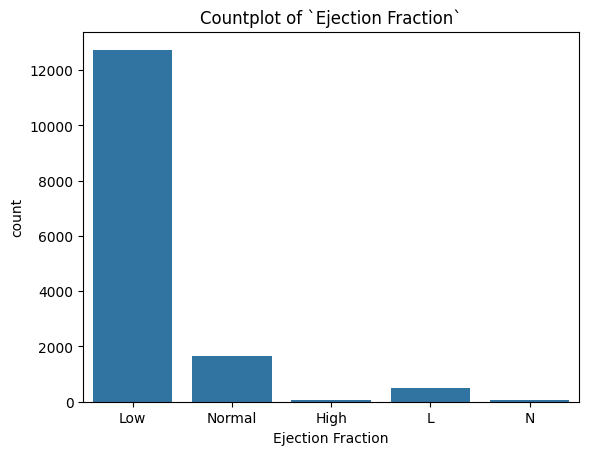

In [292]:
sns.countplot(data=df, x="Ejection Fraction")
plt.title("Countplot of `Ejection Fraction`")
plt.show()

In [293]:
df["Ejection Fraction"] = df['Ejection Fraction'].replace({"L": "Low", "N": "Normal"})
df["Ejection Fraction"].value_counts(normalize=True)

Ejection Fraction
Low       0.881067
Normal    0.114933
High      0.004000
Name: proportion, dtype: float64

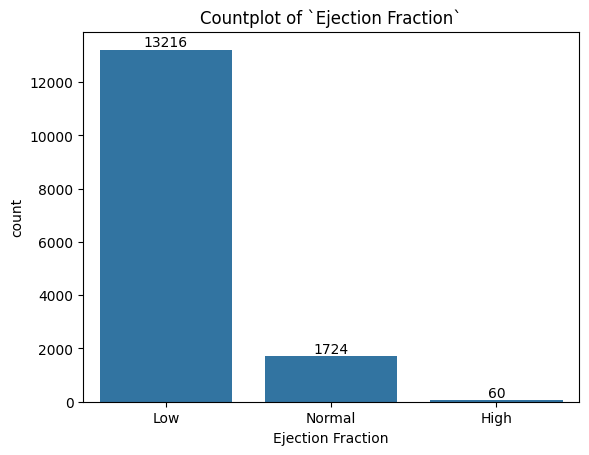

In [294]:
ef_plot = sns.countplot(data=df, x="Ejection Fraction")
ef_plot.bar_label(ef_plot.containers[0])
plt.title("Countplot of `Ejection Fraction`")
plt.show()

The `Ejection Fraction` column contains values for Low, Normal and High, as well as its shorthand notations (L, N) which have been replaced with values in full spelling using string methods.

The countplot shows `Ejection Fraction` with three levels: Low (88.1%, n= 13216), Normal (11.5%, n=1724) and High (0.4%, n=60). This is a severe class imbalance, especially since the Normal and High categories are significantly lower than the Low category. Despite this, all three levels would be maintained, both because ejection fraction is a clinically significant predictor of cardiac outcomes where even rare categories might carry real signal and to analyse the efficiency of tree-based models, which are less sensitive to sparse categories than linear models.

### Sodium

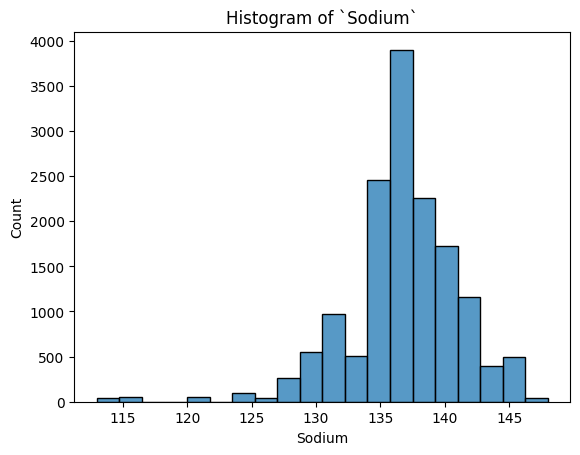

In [295]:
sns.histplot(data=df, x="Sodium", bins = 20)
plt.title("Histogram of `Sodium`")
plt.show()

In [296]:
df["Sodium"].skew()

-1.0031512181649875

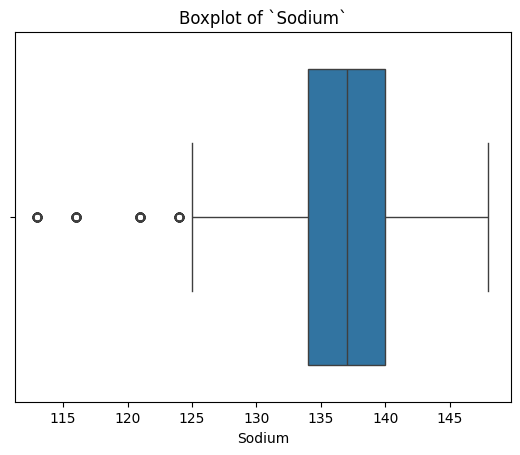

In [297]:
sns.boxplot(data=df, x="Sodium")
plt.title("Boxplot of `Sodium`")
plt.show()

In [298]:
def get_outlier(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3- q1
    lower = q1 -1.5 *iqr
    upper = q3 + 1.5*iqr

    return df[(df[col] < lower) | (df[col] > upper)]    

In [299]:
sodium_outliers = get_outlier(df, 'Sodium')

num_outliers = len(sodium_outliers)
percentage_outliers = len(sodium_outliers) * 100 / len(df)


In [300]:
num_outliers

185

In [301]:
percentage_outliers

1.2333333333333334

According to the histogram, the median `Sodium` value 137 mg/dL, with the middle 50% of data between 134 and 140 mg/dL (25th and 75th percentile) as justified by the boxplot.

The data appears to be heavily left-skewed, as shown by the -1 value in the .skew() function. This is further justified by the long left tail on the histogram, which is likely due to the 185 outliers (1.23%) below the lower whisker bound as seen on the boxplot. A suitable transformation will then be explored and applied for the `Sodium` column.

### Creatinine

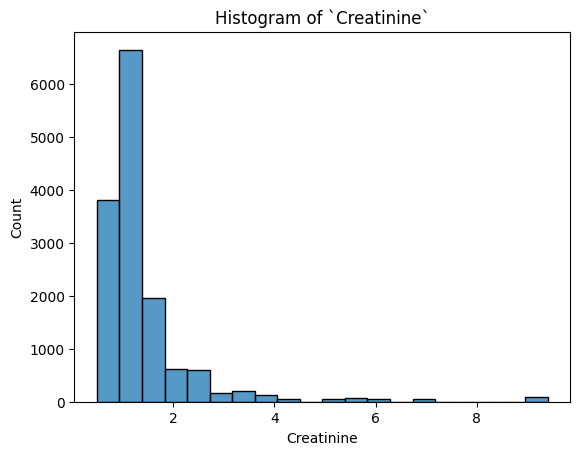

In [302]:
sns.histplot(data=df, x="Creatinine", bins = 20)
plt.title("Histogram of `Creatinine`")
plt.show()

In [303]:
df["Creatinine"].skew()

4.3266268773135135

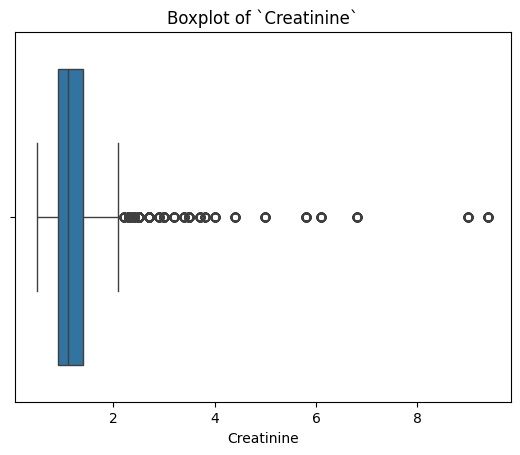

In [304]:
sns.boxplot(data=df, x="Creatinine")
plt.title("Boxplot of `Creatinine`")
plt.show()

In [305]:
creatinine_outliers = get_outlier(df, 'Creatinine')

num_outliers = len(creatinine_outliers)
percentage_outliers = len(creatinine_outliers) * 100 / len(df)

In [306]:
num_outliers

1513

In [307]:
percentage_outliers

10.086666666666666

According to the histogram, the median creatinine level is 1.1 mEq/L, with the middle 50% of data concentrated between 0.9 (25th percentile) and 1.4 mEq/L (75th percentile). Most of the data is below 2 mEq/L, with a large number of outliers (n= 1513, 10.1%) above the upper whisker bound as shown on the boxplot, which has resulted in a long right tail in the histogram. The high .skew() value of 4.33 thus further justifies that the values in the `Creatinine` column are heavily right-skewed. As such, a suitable transformation will be explained and considered for the `Creatinine` column.

### Platelets

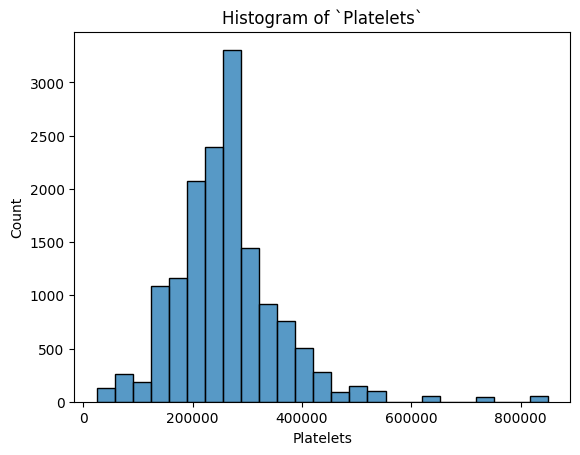

In [308]:
sns.histplot(data=df, x = "Platelets", bins = 25)
plt.title("Histogram of `Platelets`")
plt.show()

In [309]:
df["Platelets"].skew()

1.4990848203223144

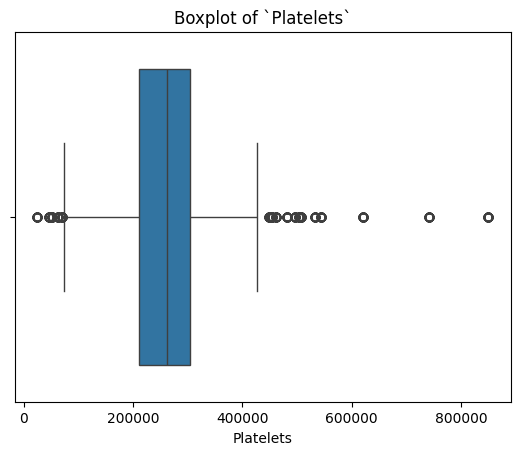

In [310]:
sns.boxplot(data=df, x = "Platelets")
plt.title("Boxplot of `Platelets`")
plt.show()

In [311]:
platelet_outliers = get_outlier(df, 'Platelets')

num_outliers = len(platelet_outliers)
percentage_outliers = len(platelet_outliers) * 100 / len(df)

In [312]:
num_outliers

941

In [313]:
percentage_outliers

6.273333333333333

According to the histogram, the median platelet level is 262000 platelets/mL, with the middle 50% of data concentrated between 211000 (25th percentile) and 304000 platelets/mL (75th percentile). The boxplot also shows that there are 941 outliers (6.27%), which are located both below and above the lower and upper whisker bound respectively. The high .skew() value of 1.50 indicates a right-skew which is observable in the histogram plot, which is likely due to the outliers extending above 400000 platelets/mL forming a long right tail. As such, a suitable transformation will be explored and applied for the `Platelets` column.

### Creatine phosphokinase

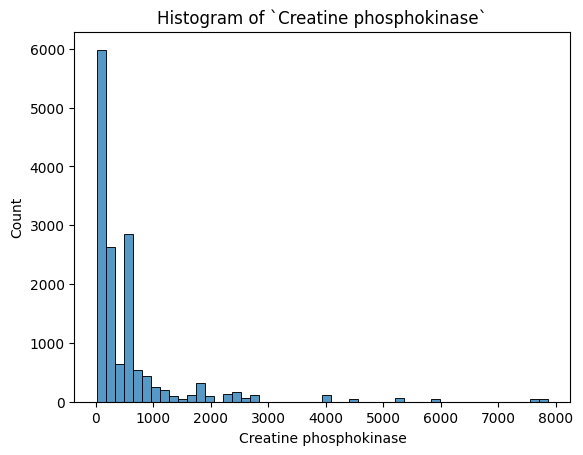

In [314]:
sns.histplot(data=df, x="Creatine phosphokinase", bins = 50)
plt.title("Histogram of `Creatine phosphokinase`")
plt.show()

In [315]:
df["Creatine phosphokinase"].skew()

4.3782081855138495

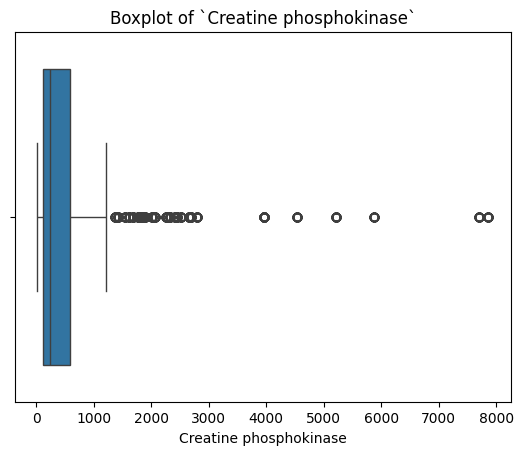

In [316]:
sns.boxplot(data=df, x="Creatine phosphokinase")
plt.title("Boxplot of `Creatine phosphokinase`")
plt.show()

In [317]:
cp_outliers = get_outlier(df, 'Creatine phosphokinase')

num_outliers = len(cp_outliers)
percentage_outliers = len(cp_outliers) * 100 / len(df)

In [318]:
num_outliers

1483

In [319]:
percentage_outliers

9.886666666666667

According to the histogram, the median Creatine phosphokinase level is 250 mcg/L, with the middle 50% of data concentrated between 115 (25th percentile) and 582 mcg/L (75th percentile). The boxplot also shows that there are 1483 outliers (9.89%), which are located above the upper whisker bound respectively. The high .skew() value of 4.38 indicates a right-skew which is observable in the histogram plot, likely due to the outliers extending above 3000 mcg/L forming a long right tail. Given the extreme right-skew and a large number of 0 values, a log1p transformation will be applied for the `Creatine phosphokinase` column.

### Blood Pressure

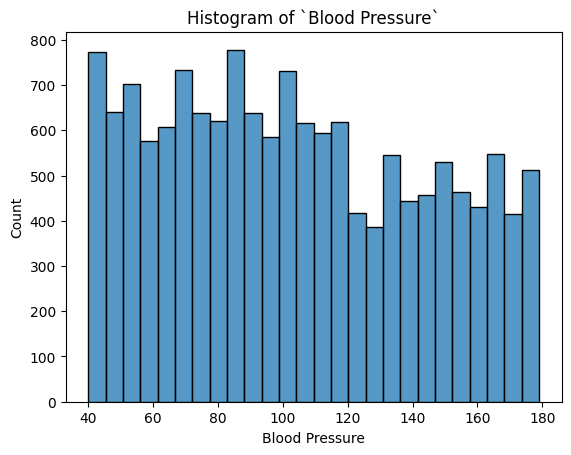

In [320]:
sns.histplot(data=df, x="Blood Pressure")
plt.title("Histogram of `Blood Pressure`")
plt.show()

In [321]:
df["Blood Pressure"].skew()

0.2064699341844608

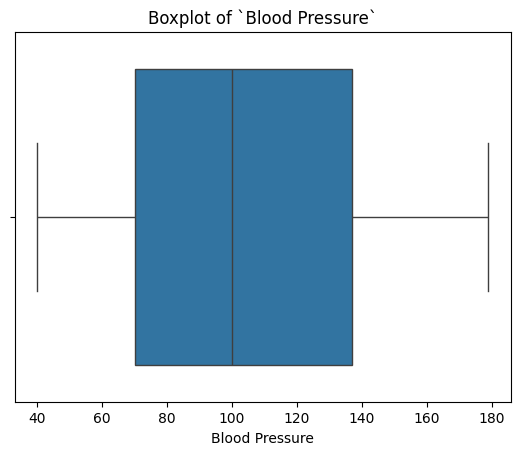

In [322]:
sns.boxplot(data=df, x= "Blood Pressure")
plt.title("Boxplot of `Blood Pressure`")
plt.show()

The `Blood Pressure` column appears roughly symmetric, with a median of 100 mmHg, with the middle 50% of values between 70 (25th percentile) and 137 mmHg (75th percentile). The boxplot also shows no visible outliers and the .skew() value of 0.2 confirms a mild skew. As such no transformation is needed for this column.

### Hemoglobin

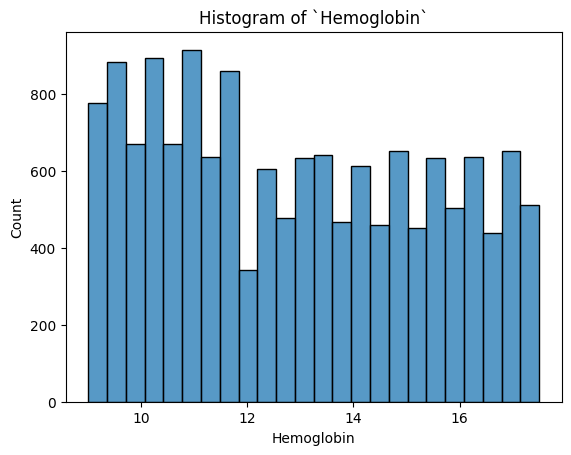

In [323]:
sns.histplot(data=df, x= "Hemoglobin")
plt.title("Histogram of `Hemoglobin`")
plt.show()

In [324]:
df["Hemoglobin"].skew()

0.1803761625770036

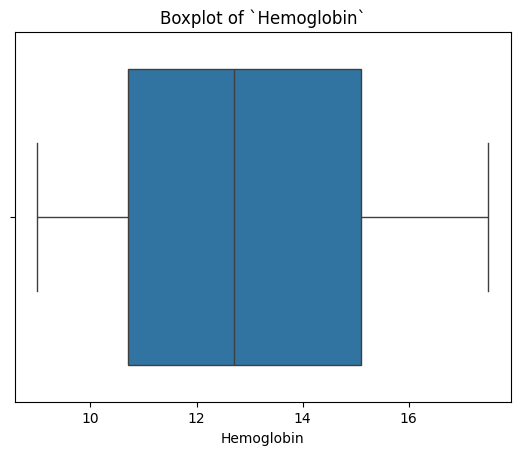

In [325]:
sns.boxplot(data=df, x= "Hemoglobin")
plt.title("Boxplot of `Hemoglobin`")
plt.show()

The values in the `Hemoglobin` column also appear roughly symmetric with a median value of 12.7 g/dL, and the middle 50% of data is between 10.7 (25th percentile) and 15.1 (75th percentile) g/dL. The boxplot shows no visible outliers, and the .skew() value of 0.18 also further justifies the mild skew. No transformation is needed for this column.

### Height

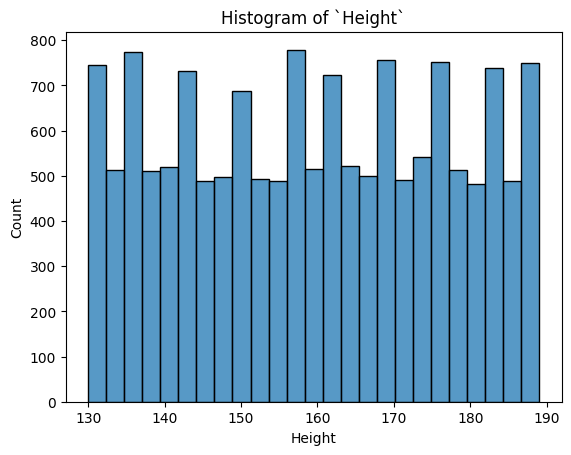

In [326]:
sns.histplot(data=df, x= "Height")
plt.title("Histogram of `Height`")
plt.show()

In [327]:
df["Height"].skew()

-0.006895684389934637

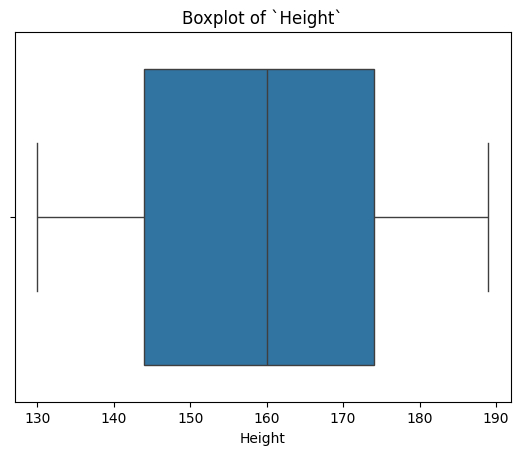

In [328]:
sns.boxplot(data=df, x= "Height")
plt.title("Boxplot of `Height`")
plt.show()

The values in the `Height` column also appear roughly symmetric with a median value of 160cm, and the middle 50% of data is between 144 (25th percentile) and 174 (75th percentile) cm. The boxplot shows no visible outliers, and the .skew() value of -0.01 also further justifies the negligible skew. No transformation is needed for this column. It is also notable that this histogram has alternating peaks and valleys, as opposed to a smooth distribution which suggests a possible rounding or data generation artifact as opposed to genuine variation in the underlying population. 

### Weight

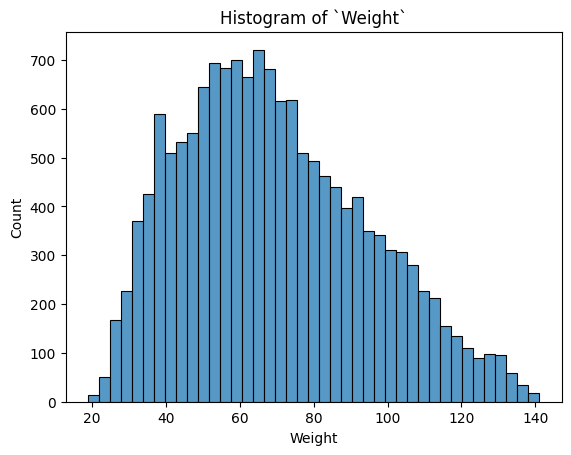

In [329]:
sns.histplot(data=df, x= "Weight")
plt.title("Histogram of `Weight`")
plt.show()

In [330]:
df["Weight"].skew()

0.4438460233477743

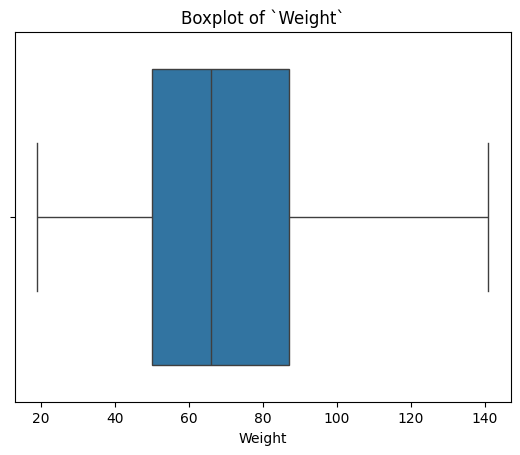

In [331]:
sns.boxplot(data=df, x= "Weight")
plt.title("Boxplot of `Weight`")
plt.show()

The values in the `Weight` column have a median value of 66kg, with the middle 50% of values being between 50 (25th percentile) and 87kg (75th percentile). The boxplot shows no visible outliers, and the histogram shows that the values in the Weight column have a visible right skew, as shown by the moderate .skew() value of 0.44. The distribution looks smooth and organic, and a transformation will be considered during model development, although less severe than that of heavily-skewed columns.

### Favorite color

In [332]:
df["Favorite color"].value_counts(normalize=True)

Favorite color
blue      0.168800
yellow    0.168667
green     0.167133
red       0.166067
white     0.165067
black     0.164267
Name: proportion, dtype: float64

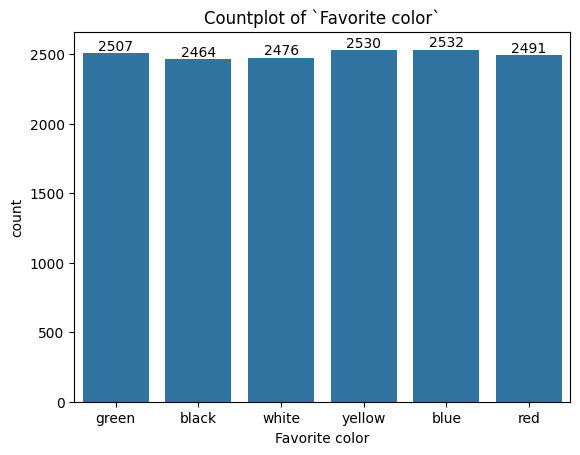

In [333]:
color_plot = sns.countplot(data=df, x="Favorite color")
color_plot.bar_label(color_plot.containers[0])
plt.title("Countplot of `Favorite color`")
plt.show()

The countplot of `Favorite color` shows a very even distribution of patients across the 6 colors, accounting for about 16-17% of the entire dataset each. Blue is the modal favorite color (n=2532, 16.9%), with yellow as close second (n=2530, 16.9%). The least popular color was black (n=2464, 16.4%).

## 5. Bivariate Analysis

In [334]:
numeric_features = df.select_dtypes(include=['number']).drop(columns=['Survive']).columns
numeric_features

Index(['Age', 'Sodium', 'Creatinine', 'Platelets', 'Creatine phosphokinase',
       'Blood Pressure', 'Hemoglobin', 'Height', 'Weight'],
      dtype='object')

### Numeric Features vs Target

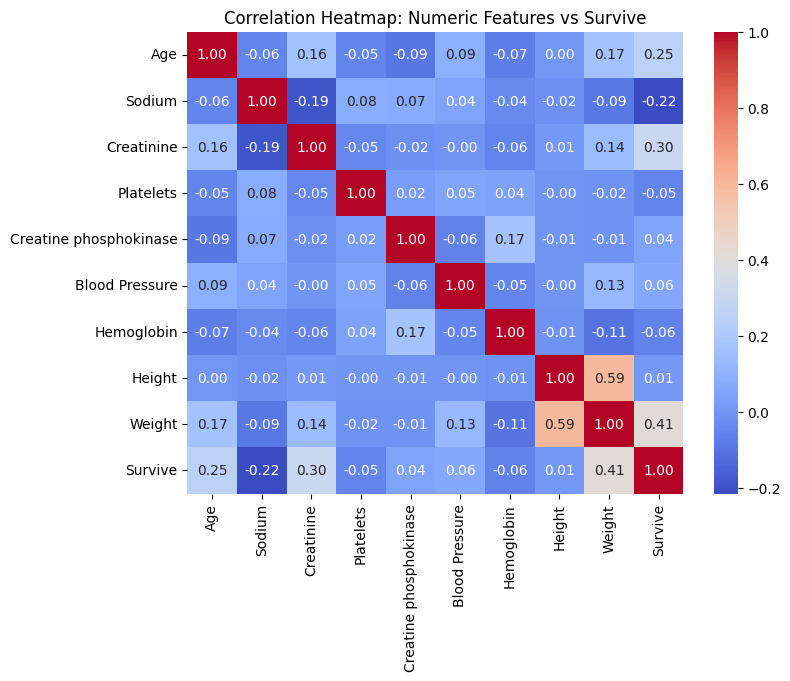

In [335]:
num_corr = df[numeric_features.tolist() + ["Survive"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(num_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Numeric Features vs Survive")
plt.show()

The correlation heatmap shows that `Weight` has the strongest positive linear correlation with the survival (r=0.41), followed by `Creatinine` (r=0.30), `Age` (r=0.25) and then `Sodium`(r=-0.22). These are weak-to-moderate correlations individually, suggesting that a combination of features is likely to predict survival as opposed to one dominant predictor.

The heatmap also highlights a multicollinearity issue, with a Pearson correlation coefficient of r = 0.59 between `Height` and `Weight`. This is reasonable as an individual that is taller is likely to weigh heavier. However, what is interesting was that `Weight` has a very strong linear correlation with the target variable (r=0.41) whereas `Height` has no linear correlation at all (r=0.01), possibly reflecting that weight carries information beyond what is explained by height alone such as nutritional or muscle-mass status in relevance to cardiac outcomes.

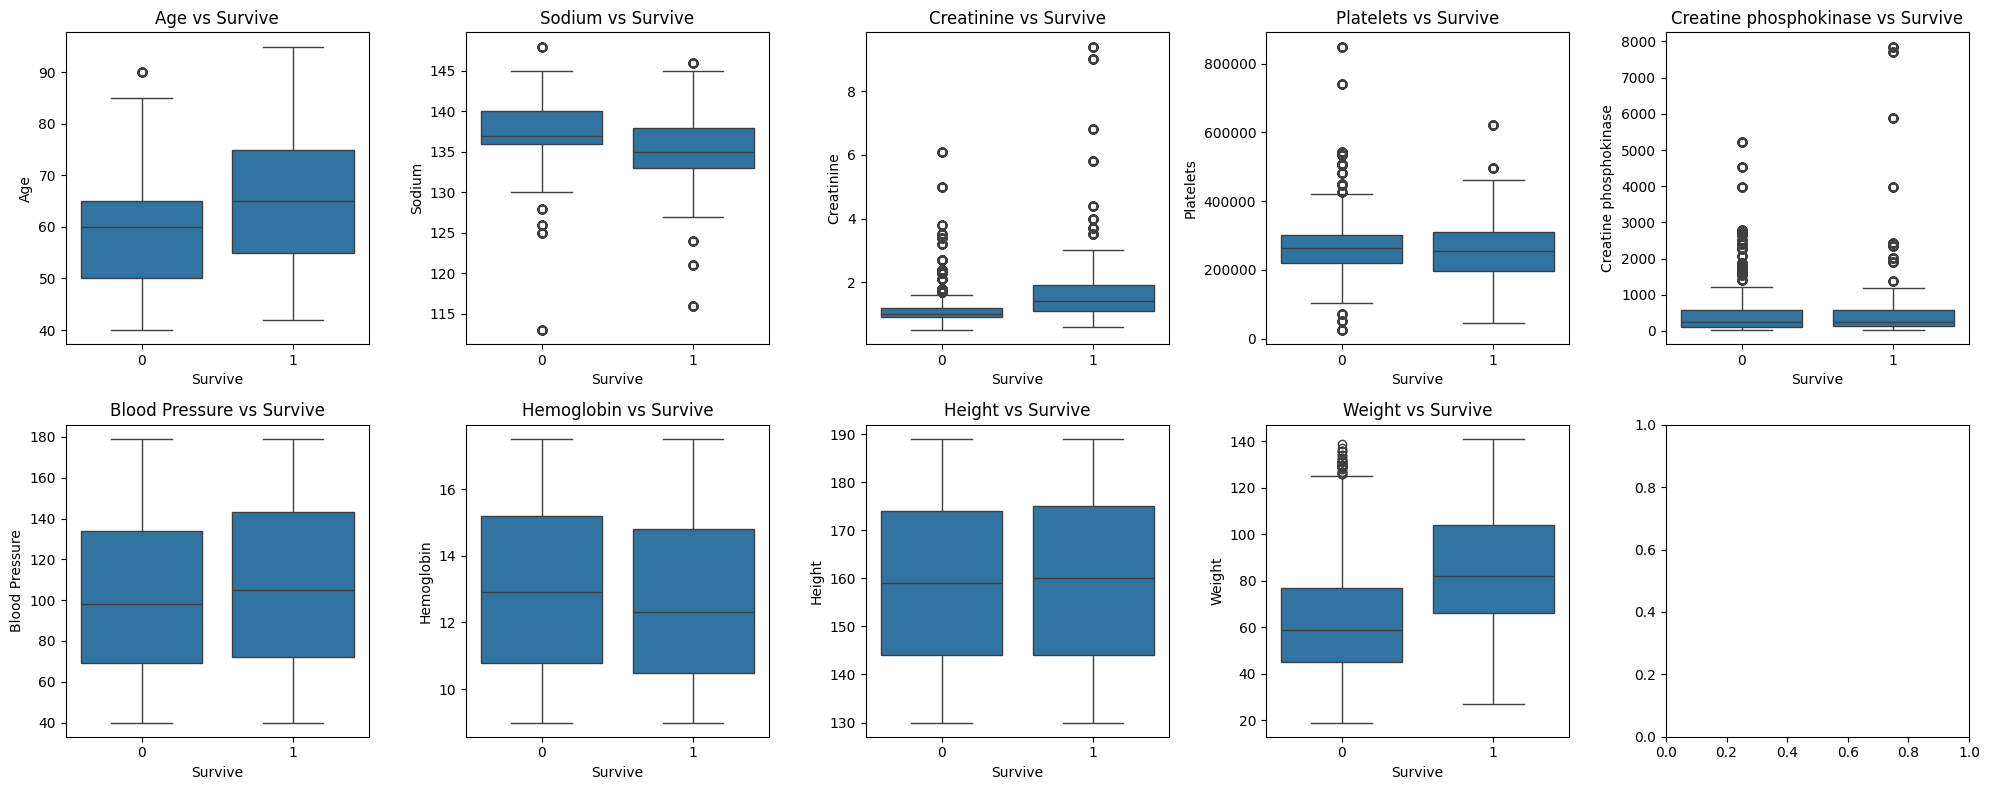

In [336]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x="Survive", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Survive")

plt.tight_layout()
plt.show()

In [337]:
results = []

for col in numeric_features:
    group0 = df[df["Survive"] == 0][col].dropna()
    group1 = df[df["Survive"] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(group0, group1, alternative="two-sided")

    results.append({
        "Feature": col,
        "U-stat": stat,
        "p-val": p,
        "Significant (a = 0.05)": p < 0.05
    })

results_df = pd.DataFrame(results).sort_values("p-val")
results_df

,Feature,U-stat,p-val,Significant (a = 0.05)
2,Creatinine,12339640.0,0.000000e+00,True
8,Weight,12284326.5,0.000000e+00,True
1,Sodium,31464672.5,1.437043e-174,True
0,Age,17858530.0,3.902206e-160,True
6,Hemoglobin,26313730.0,4.372530e-13,True
5,Blood Pressure,22761954.0,1.228261e-12,True
3,Platelets,26067983.0,4.042356e-10,True
4,Creatine phosphokinase,24313539.5,4.025933e-01,False
7,Height,24333765.5,4.509500e-01,False


The boxplot of each numeric feature grouped by `Survive` show varying degrees of separation between the two classes. `Age`, `Sodium`, `Creatinine` and `Weight` show visible shifts in median as well as differences in box overlap between survivors and non-survivors which were consistent with the stronger correlations observed in the heatmap. In contrast, `Platelets`, `Creatine phosphokinase`, `Blood Pressure`, `Hemoglobin` and `Height` shows heavy overlapping distributions between groups, consistent with their near-zero correlation values.


A Mann-Whitney U test was performed for each numeric feature against the `Survive` column due to the non-normal, skewed distributions as seen in the univariate analysis.

At a=0.05, seven of the nine numeric features are statistically significant, with only `Creatine phosphokinase` and `Height` failing to reach significance. However, statistical signficance does not always align with feature importance. `Creatinine`, `Weight`, `Sodium` and `Age` are both signficant and show correlation with `Survive`, making them strong candidates with predictive power. `Hemoglobin`, `Blood Pressure` and `Platelets` are statistically significant but show negligible correlation ,which is likely a consequence of the large sample size (n=15000) as opposed to having practical meaningful relationship.

Rather than excluding these three features based on univariate analysis alone, they will be retained through initial model training with their contributions reassessed before finalizing the feature set.

### Categorical Features vs Target

In [338]:
categorical_features = df.select_dtypes(include=['object']).drop(columns=['ID']).columns.tolist()
categorical_features

['Gender', 'Smoke', 'Diabetes', 'Ejection Fraction', 'Favorite color']

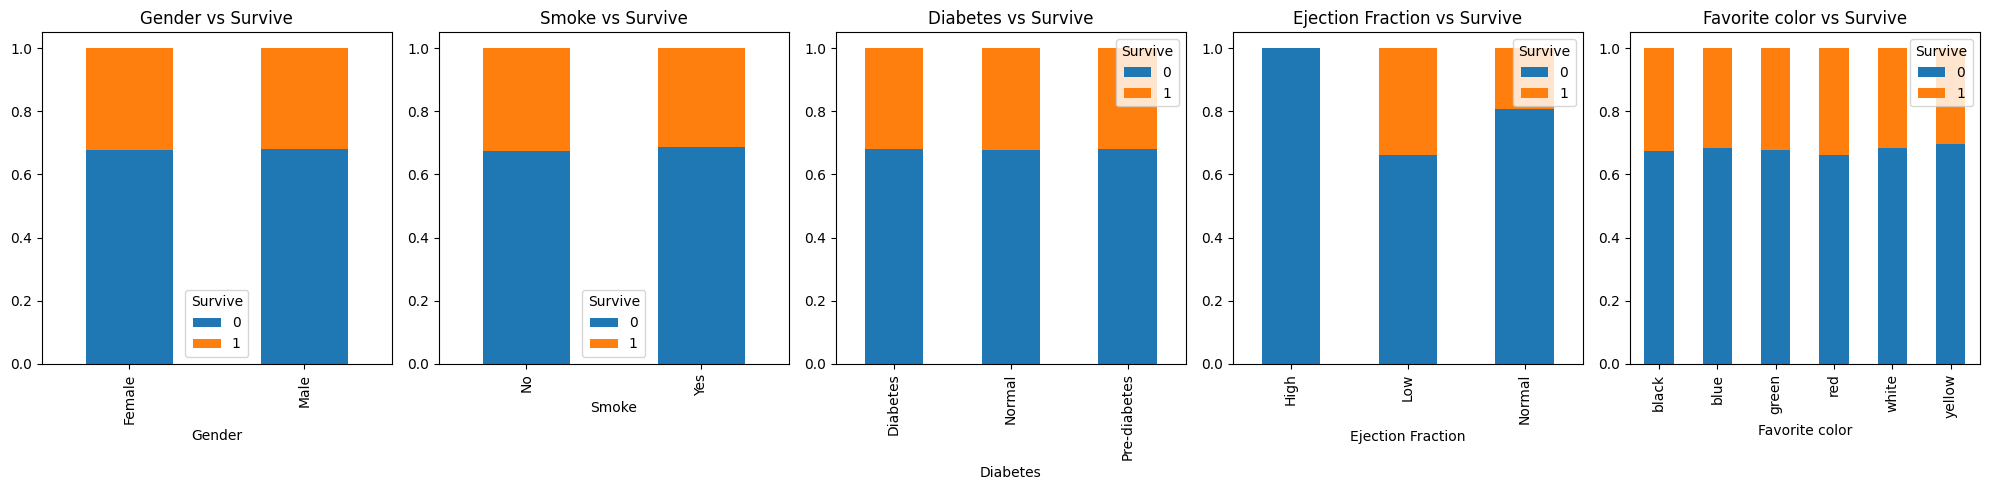

In [339]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(20, 5))
for i, col in enumerate(categorical_features):
    pd.crosstab(df[col], df["Survive"], normalize="index").plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(f"{col} vs Survive")
    axes[i].legend(title="Survive")
plt.tight_layout()
plt.show()

Normalized stacked bar charts were plotted for each categorical feature to visualise the proportion of surviviros within each category. `Gender`, `Smoke`, `Diabetes` and `Favorite Color` show near-identical survival proportions across their respective categories, suggesting little to no relationship with `Survive`. 

In contrast, `Ejection Fraction` shows a clear gradient in survival proportion across its levels, with Low corresponding to visibly poorer survival than Normal, and High showing the highest apparent survival proportion, ahtough this observation should be treated cautiously given the category's very small sample size (n=60, 0.4%).

In [340]:
results = []

for col in categorical_features:
    contingency= pd.crosstab(df[col], df["Survive"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append({
        "Feature": col,
        "Chi2": chi2,
        "p-val": p,
        "Significant (a=0.05)": p < 0.05
    })

cat_results_df = pd.DataFrame(results).sort_values("p-val")
cat_results_df

,Feature,Chi2,p-val,Significant (a=0.05)
3,Ejection Fraction,180.275221,7.140574e-40,True
1,Smoke,2.172935,1.404580e-01,False
4,Favorite color,7.023795,2.188766e-01,False
0,Gender,0.056787,8.116489e-01,False
2,Diabetes,0.010362,9.948326e-01,False


To statistically validate these visual observations, a Chi-Square test of independence was performed for each categorical feature against `Survive`. 

Only `Ejection Fraction` shows a statistical association with survival, confirming the pattern seen in the stacked bar charts and consistent with its known clinical relevance as a measure of cardiac function. `Gender`, `Smoke` and `Diabetes` show no significant relationship despite plausible real-world clinical relevance, which may reflect sample-specific characteristics of this dataset rather than true absence of effect. 

Importantly, `Favorite Color` is also non significant (p=0.219), further reinforcing its earlier classification as a synthetic feature with no relationship to patient outcomes, so it will be excluded from modelling.

### Feature-Feature Analysis (Cat)

In [341]:
def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

results = []

for col1, col2 in combinations(categorical_features,2):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    v = cramers_v(chi2, contingency)
    results.append({
        "Feature 1": col1,
        "Feature 2": col2,
        "Chi2": chi2,
        "p-val": p,
        "Cramer's V": v,
        "Significant (a=0.05)": p < 0.05
    })

catcat_results_df = pd.DataFrame(results).sort_values("Cramer's V", ascending= False)
catcat_results_df

,Feature 1,Feature 2,Chi2,p-val,Cramer's V,Significant (a=0.05)
0,Gender,Smoke,2962.672589,0.000000e+00,0.444423,True
1,Gender,Diabetes,307.092629,2.068631e-67,0.143083,True
2,Gender,Ejection Fraction,282.276221,5.064043e-62,0.137180,True
4,Smoke,Diabetes,249.468971,6.737537e-55,0.128962,True
5,Smoke,Ejection Fraction,36.427022,1.230191e-08,0.049279,True
7,Diabetes,Ejection Fraction,43.095692,9.885405e-09,0.037901,True
9,Ejection Fraction,Favorite color,16.754384,7.997860e-02,0.023632,False
6,Smoke,Favorite color,6.587876,2.531381e-01,0.020957,False
8,Diabetes,Favorite color,6.472432,7.741340e-01,0.014688,False
3,Gender,Favorite color,1.462118,9.173995e-01,0.009873,False


A pairwise Chi-square test with Cramer's V was performed across all categorical features to assess redundancy. While nearly all pairs are statistically significant (a function of the large sample size), effect sizes vary considerably.

`Gender` and `Smoke` show the only association of practical concern (Cramer V = 0.44, moderate), which is notably higher than every other pair, suggesting that smoking behavior differs considerably by gender in this dataset. All other pairs show weak association (V < 0.15).

However, since the earlier target-relationship analysis only showed `Ejection Fraction` having a statistically significant association with `Survive`, this feature-feature redundancy between `Gender` and `Smoke` does not affect the final feature set. The pairwise associations of `Ejection Fraction` with other categorical features all appear weak (V < 0.14) so it will be retained without any concerns of multicollinearity.

## 6. Feature Selection

Numeric Features:

- `Age`, `Weight`, `Creatinine`, `Sodium`: weak-to-moderate linear correlation to target, statistically significant in Mann-Whitney U-test. Retained for modelling.
- `Hemoglobin`, `Blood Pressure`, `Platelets`: very weak linear correlation to target, however statistically significant in Mann-Whitney U-test. Retained for model-based reassessment
- `Creatine phosphokinase`, `Height`: very weak linear correlation to target and not statistically significant in Mann-Whitney U-test. Dropped from modelling.

Categorical Features:
- `Ejection Fraction`: differences in survival across categories, Chi2 test shows statistical significance with target variable. Column retained for modelling.
- `Gender`, `Smoke`, `Diabetes`, `Favorite Color`: no significant difference in survival across respective categories, and Chi2 test shows no statistical significance with target variable. Columns dropped.

## 7. Data Splitting

In [342]:
sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_val_idx, test_idx = next(sgkf1.split(df, df["Survive"],groups=df["ID"]))

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf2.split(train_val_df, train_val_df["Survive"], groups=train_val_df["ID"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {train_df['ID'].nunique()} patients")
print(f"Validation: {len(val_df)} rows, {val_df['ID'].nunique()} patients")
print(f"Test: {len(test_df)} rows, {test_df['ID'].nunique()} patients")



Train: 9574 rows, 8979 patients
Validation: 2404 rows, 2255 patients
Test: 3022 rows, 2808 patients


In [343]:
train_ids, val_ids, test_ids = set(train_df['ID']), set(val_df["ID"]), set(test_df["ID"])
print(f"Train-Val overlap: {len(train_ids & val_ids)}")
print(f"Train-Test overlap: {len(train_ids & test_ids)}")
print(f"Val-Test overlap: {len(val_ids & test_ids)}")

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [344]:
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name}: {d['Survive'].value_counts(normalize=True)}")

Train: Survive
0    0.678191
1    0.321809
Name: proportion, dtype: float64
Val: Survive
0    0.684276
1    0.315724
Name: proportion, dtype: float64
Test: Survive
0    0.677366
1    0.322634
Name: proportion, dtype: float64


To prevent data leakage from the same patient appearing across multiple sets (as seen in the univariate analysis of `ID`), the dataset was split using `StratifiedGroupKFold`, grouping by `ID` and then stratifying on `Survive`. This was performed in two stages: first splitting off a test set (20% of data), then splitting the remaining data into train and validation sets (64%, 16%). This yields an approximate 64/16/20 train/validation/test split.

- Train: 9574 rows, 8979 patients
- Validation: 2404 rows, 2255 patients
- Test: 3022 rows, 2808 patients

No patient `ID` appears more than once in another set, confirming that the split is leakage-free. Class balance for `Survive` was preserved across the three sets to match the original 67.9%/32.1% distribution:

- Train: 67.8% / 32.2%
- Validation: 68.4% / 31.6%
- Test: 67.7% / 32.3%

## 8. Data Preprocessing

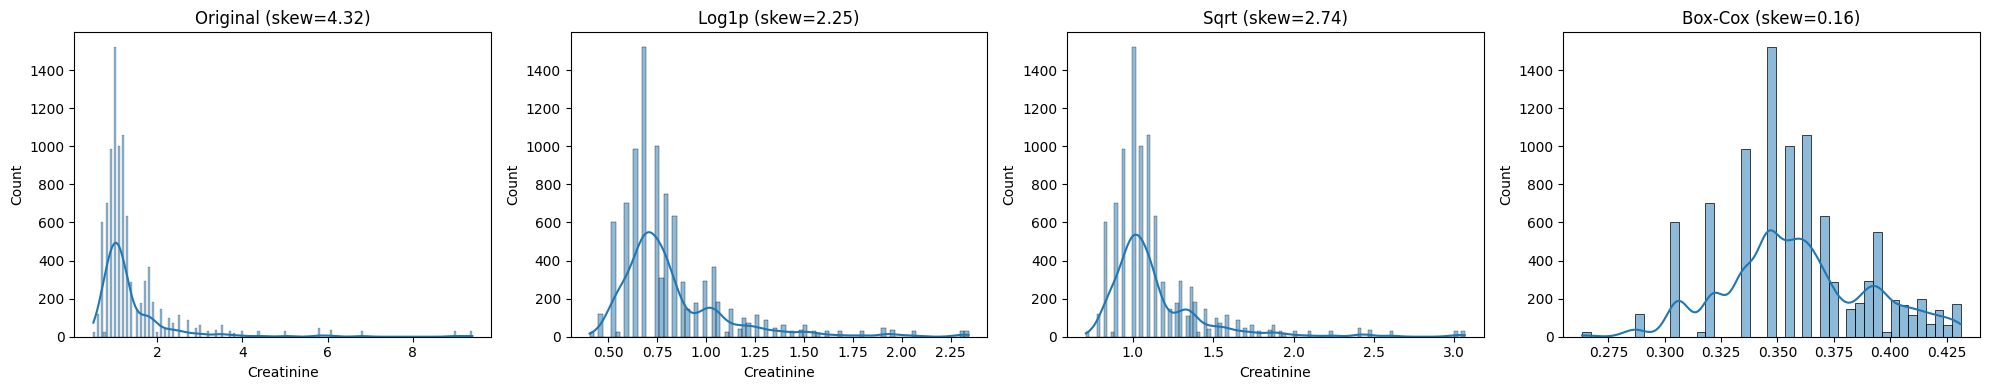

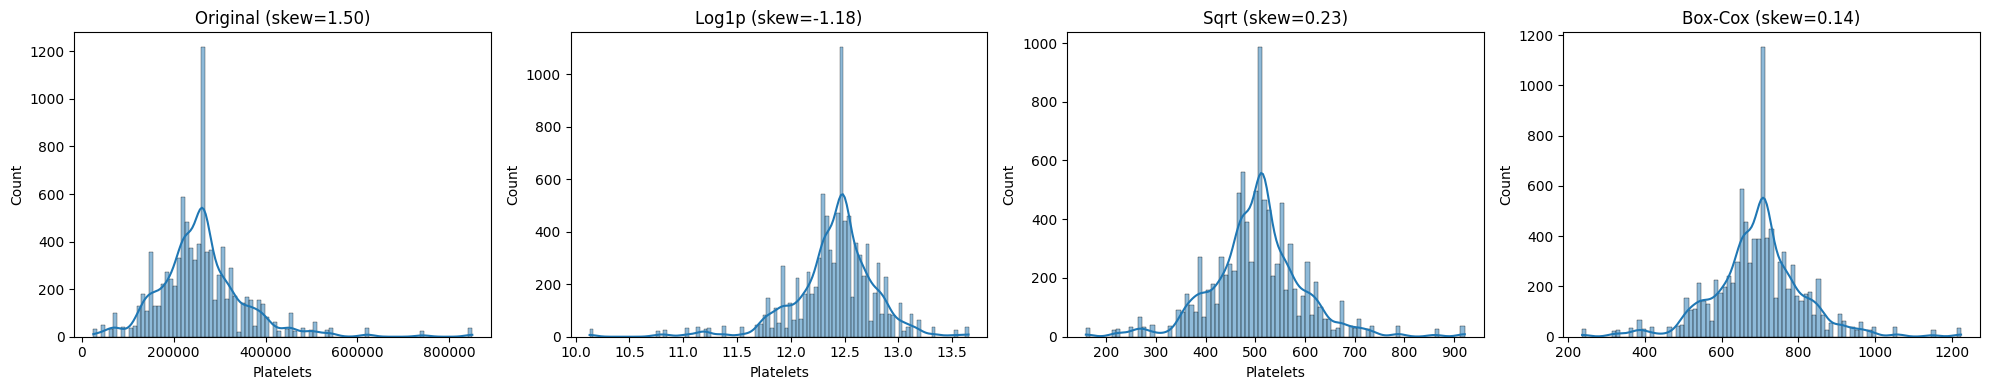

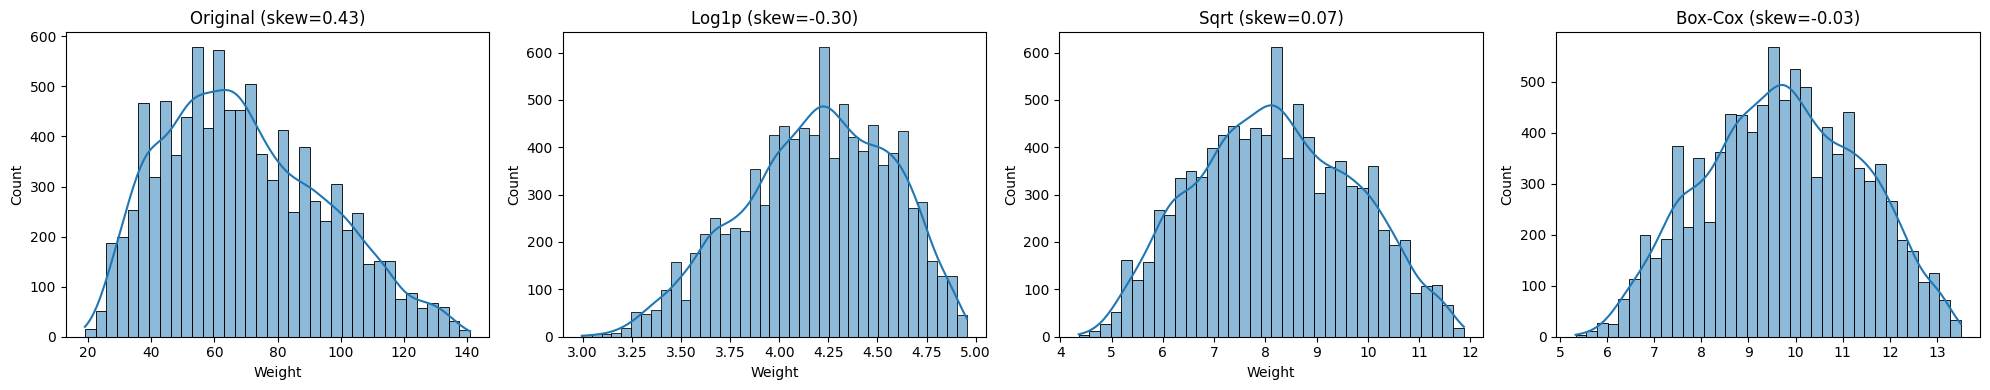

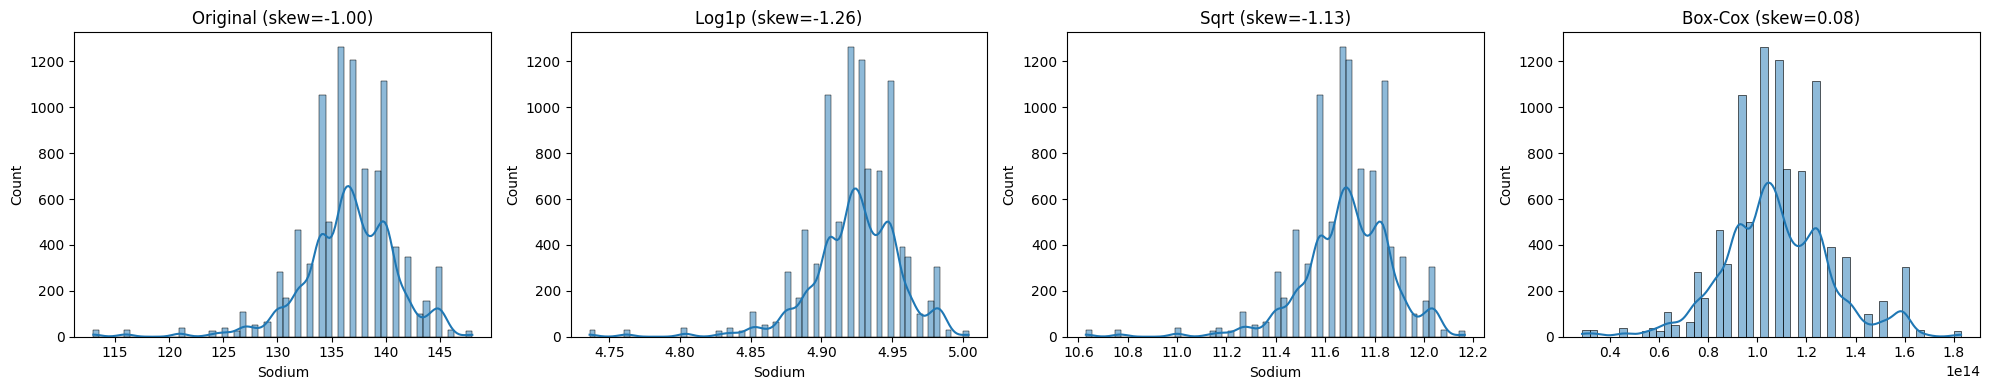

In [345]:
def compare_transforms(df, col):
    original = df[col].dropna()
    log1p = np.log1p(original)
    sqrt = np.sqrt(original)
    boxcox_vals, _ = stats.boxcox(original + 1)
    boxcox = pd.Series(boxcox_vals, index = original.index)

    fig, axes = plt.subplots(1,4, figsize =  (20,4))
    for ax, data, name in zip(axes, [original, log1p, sqrt, boxcox], ["Original", "Log1p", "Sqrt", "Box-Cox"]):
        sns.histplot(data, ax=ax, kde=True)
        ax.set_title(f"{name} (skew={data.skew():.2f})")
    plt.tight_layout()
    plt.show()

compare_transforms(train_df, "Creatinine")
compare_transforms(train_df, "Platelets")
compare_transforms(train_df, "Weight")
compare_transforms(train_df, "Sodium")

**Creatinine**: original dataset has a .skew() value of 4.32 and is heavily right-skewed. Box-Cox significantly reduced skew as seen by the near symmetric bell-shaped distribution with a low .skew() value of 0.16. Additionally, Box-Cox is the only transformation that has meaningfully addressed the extreme skew.

**Platelets**: original dataset has a .skew() value of 1.50 and is also right-skewed. Square root (.skew() = 0.23) and Box-Cox (.skew() = 0.14) are both suitable transformations for the column, however Square Root will be used due to its ease of interpretability.

**Weight**: original dataset has a .skew() value of 0.43 with a mild right skew. All three transformations work reasonably, but Square Root would be used due to its ease of interpretation.

**Sodium**: original dataset has a .skew() value of -1.00 with a left skew. Box-Cox has significantly reduced the skew as seen by the near-symmetric bell-shaped distribution with a low .skew() value of 0.08. Additionally, Box-Cox is the only transformation that has meaningfully addressed the extreme skew.

In [348]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PowerTransformer, FunctionTransformer

creatinine_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("boxcox", PowerTransformer(method="box-cox")),
    ("scaler", StandardScaler())
])

sodium_pipe = Pipeline(steps=[
    ("boxcox", PowerTransformer(method="box-cox")),
    ("scaler", StandardScaler())
])

platelets_pipe = Pipeline(steps=[
    ("sqrt", FunctionTransformer(np.sqrt, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

weight_pipe = Pipeline(steps=[
    ("sqrt", FunctionTransformer(np.sqrt, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

plain_numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

ef_encoder = OrdinalEncoder(categories= [["Low", "Normal", "High"]])

preprocessor = ColumnTransformer([
    ("creatinine", creatinine_pipe, ["Creatinine"]),
    ("sodium", sodium_pipe, ["Sodium"]),
    ("platelets", platelets_pipe, ["Platelets"]),
    ("weight", weight_pipe, ["Weight"]),
    ("plain_numeric", plain_numeric_pipe, ["Blood Pressure", "Hemoglobin", "Age"]),
    ("ejection fraction", ef_encoder, ["Ejection Fraction"])
])


In [351]:
X_train = preprocessor.fit_transform(train_df)
X_val = preprocessor.transform(val_df)
X_test = preprocessor.transform(test_df)

y_train = train_df["Survive"]
y_val = val_df["Survive"]
y_test = test_df["Survive"]


## 9. Model Training

In [354]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedGroupKFold

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

scoring = {
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc",
    "F1": "f1"
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    cv_results = cross_validate(
        model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1,
        groups = train_df["ID"]
    )

    results.append({
        "model": name,
        "PR-AUC": np.mean(cv_results["test_PR-AUC"]),
        "ROC-AUC": np.mean(cv_results["test_ROC-AUC"]),
        "F1": np.mean(cv_results["test_F1"])
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC",ascending=False)
results_df

,model,PR-AUC,ROC-AUC,F1
2,XGBoost,0.999997,0.999999,0.999850
1,Random Forest,0.999995,0.999998,0.998396
0,Logistic Regression,0.719431,0.840192,0.620350


In [357]:
from sklearn.tree import DecisionTreeClassifier

for depth in [3, 4, 5, 6, 8, 10, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    val_acc = tree.score(X_val, y_val)
    print(f"Depth {depth}: Train acc={train_acc:.4f}, Val acc={val_acc:.4f}")

Depth 3: Train acc=0.7929, Val acc=0.8087
Depth 4: Train acc=0.8309, Val acc=0.8469
Depth 5: Train acc=0.8473, Val acc=0.8573
Depth 6: Train acc=0.8813, Val acc=0.8823
Depth 8: Train acc=0.9392, Val acc=0.9351
Depth 10: Train acc=0.9669, Val acc=0.9601
Depth None: Train acc=1.0000, Val acc=0.9938


Tree-based models like Random Forest and XGBoost achieved near-perfect PR-AUC (0.99) on this dataset whereas Logistic Regression achieved only a moderate 0.72. A depth-sweep of a standalone decision tree showed train and validation accuracy tracking closely at every depth (e.g. 0.97/0.96 at depth 10, 1.00/0.99 unconstrained), ruling out overfitting or data leakage as the cause.

This pattern suggests `Survive` was generated from a deterministic or near-deterministic combination of small features, learnable by threshold splitting models but not representable by a purely linear model like Logistic Regression. This is consistent with other synthetic characteristics identified during EDA (e.g. `Favorite Color`, the artificial banding pattern in `Height`), reinforcing that this dataset was likely constructed rather than sourced from genuine noisy clinical records.

## 10. Feature Importance

In [358]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train, y_train)

xgb_final = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_final.fit(X_train, y_train)

feature_names = preprocessor.get_feature_names_out()

comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_final.feature_importances_,
    "XGB Importance": xgb_final.feature_importances_,
    "LogReg |Coefficient|": np.abs(log_reg.coef_[0])
}).sort_values("RF Importance", ascending=False)

comparison_df

,Feature,RF Importance,XGB Importance,LogReg |Coefficient|
0,creatinine__Creatinine,0.245312,0.209546,0.802409
2,platelets__Platelets,0.188508,0.093273,0.084870
6,plain_numeric__Age,0.165495,0.094648,0.334516
1,sodium__Sodium,0.159446,0.083853,0.252977
3,weight__Weight,0.135565,0.340158,1.015716
5,plain_numeric__Hemoglobin,0.043811,0.047213,0.043696
4,plain_numeric__Blood Pressure,0.042619,0.043268,0.066159
7,ejection fraction__Ejection Fraction,0.019244,0.088039,0.849940


Following feature importance analysis across RF, XGB and LogReg coefficients, `Hemoglobin` and `Blood Pressure` consistently ranked lowest across all three models and should be dropped from the final feature set. `Platelets` despite having weak univariate correlation, showed meaningful importance in Random Forest (0.19), likely capturing an interaction effect that is not visible in linear correlation and thus is kept in the final feature set.

## 11. Rebuilding the Pipeline

In [359]:
preprocessor = ColumnTransformer([
    ("creatinine", creatinine_pipe, ["Creatinine"]),
    ("sodium", sodium_pipe, ["Sodium"]),
    ("platelets", platelets_pipe, ["Platelets"]),
    ("weight", weight_pipe, ["Weight"]),
    ("plain_numeric", plain_numeric_pipe, ["Age"]),
    ("ejection fraction", ef_encoder, ["Ejection Fraction"])
])

X_train = preprocessor.fit_transform(train_df)
X_val = preprocessor.transform(val_df)
X_test = preprocessor.transform(test_df)

y_train = train_df["Survive"]
y_val = val_df["Survive"]
y_test = test_df["Survive"]

In [360]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train, y_train)

xgb_final = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_final.fit(X_train, y_train)

feature_names = preprocessor.get_feature_names_out()

comparison_df = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_final.feature_importances_,
    "XGB Importance": xgb_final.feature_importances_,
    "LogReg |Coefficient|": np.abs(log_reg.coef_[0])
}).sort_values("RF Importance", ascending=False)

comparison_df

,Feature,RF Importance,XGB Importance,LogReg |Coefficient|
0,creatinine__Creatinine,0.277955,0.230161,0.794454
2,platelets__Platelets,0.208896,0.100453,0.079936
4,plain_numeric__Age,0.189810,0.098083,0.340395
1,sodium__Sodium,0.159748,0.101407,0.250263
3,weight__Weight,0.142585,0.323083,1.027810
5,ejection fraction__Ejection Fraction,0.021007,0.146813,0.848219


## 12. Hyperparameter Tuning

In [362]:
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

xgb_params = {
    "n_estimators": [100,200,300],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metrics="logloss"),
    xgb_params, n_iter=15, cv=cv, scoring="average_precision",
    random_state=42, n_jobs=-1
)

xgb_search.fit(X_train, y_train, groups=train_df["ID"])

print(f"Best PR-AUC: {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

/Users/nathan/Personal_Projects/heart_disease_survival_prediction/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:00:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nathan/Personal_Projects/heart_disease_survival_prediction/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:00:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nathan/Personal_Projects/heart_disease_survival_prediction/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:00:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/nathan/Personal_Projects/heart_disease_survival_prediction/venv/lib/python3.11/si

Best PR-AUC: 1.0000
Best params: {'subsample': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}


[19:00:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.



Given computational constraints and that Random Forest and XGBoost already achieved near-perfect PR-AUC (0.99) at baseline, tuning effort was focused on XGBoost using RandomizedSearchCV and StratifiedGroupKFold (grouped by `ID`, consistent with the leakage-prevention approach used throughout).

Tuning achieved a best cross-validated PR-AUC of 1.00, with optimal parameters: 
- subsample =1
- n_estimators = 200,
- max_depth = 5,
- learning_rate = 0.2

This improvement over the untuned baseline is consistent with the earlier finding that `Survive` is generated from a near-deterministic combination of features, leaving little headroom for tuning to improve upon.

## 13. Final Test Set Evaluation

In [364]:
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score

xgb_final_tuned = xgb_search.best_estimator_

test_preds = xgb_final_tuned.predict(X_test)
test_probs = xgb_final_tuned.predict_proba(X_test)[:, 1]

print(classification_report(y_test, test_preds))
print(f"Test PR-AUC: {average_precision_score(y_test, test_preds):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2047
           1       1.00      1.00      1.00       975

    accuracy                           1.00      3022
   macro avg       1.00      1.00      1.00      3022
weighted avg       1.00      1.00      1.00      3022

Test PR-AUC: 1.0000
Test ROC-AUC: 1.0000


## Final Test Set Evaluation

The tuned XGBoost model was evaluated once on the untouched test set, achieving perfect precision, recall, and F1-score (1.00) across both classes, with PR-AUC = 1.0000 and ROC-AUC = 1.0000. These results closely match validation performance, confirming the model generalizes well with no evidence of overfitting.

The consistently near-perfect performance across cross-validation, validation, and test sets — combined with the earlier depth-sweep diagnostic showing train/validation accuracy tracking closely at every tree depth — supports the conclusion that `Survive` follows a deterministic or near-deterministic rule derivable from a small set of features, rather than reflecting the noise typical of real clinical outcomes. This is consistent with other synthetic characteristics identified during EDA (`Favourite Color`, the artificial banding pattern in `Height`), reinforcing that this dataset was likely constructed for evaluation purposes rather than sourced from genuine patient records.